#**Preprocessing**

In [1]:
#install pandas
!pip install pandas

# Import library yang diperlukan
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

In [ ]:
# Membaca dataset NYC
file_nyc = '/content/dataset_TSMC2014_NYC.csv'
df_nyc = pd.read_csv(file_nyc)

# Membaca dataset Tokyo
file_tky = '/content/dataset_TSMC2014_TKY.csv'
df_tky = pd.read_csv(file_tky)

# Menampilkan informasi awal dari kedua dataset
print("Informasi Dataset NYC:")
print(df_nyc.info())
print("\nInformasi Dataset Tokyo:")
print(df_tky.info())

In [ ]:
# Mengecek missing values di dataset NYC
print("\nMissing values di dataset NYC:")
print(df_nyc.isnull().sum())

# Mengecek missing values di dataset Tokyo
print("\nMissing values di dataset Tokyo:")
print(df_tky.isnull().sum())

# Mengisi missing values dengan 'Unknown' untuk kolom string
df_nyc.fillna('Unknown', inplace=True)
df_tky.fillna('Unknown', inplace=True)

# Mengecek dan menghapus data duplikat di dataset NYC
print("\nJumlah data duplikat di dataset NYC:", df_nyc.duplicated().sum())
df_nyc = df_nyc.drop_duplicates()

# Mengecek dan menghapus data duplikat di dataset Tokyo
print("\nJumlah data duplikat di dataset Tokyo:", df_tky.duplicated().sum())
df_tky = df_tky.drop_duplicates()

# Menyimpan dataset NYC yang sudah diproses
df_nyc.to_csv('/content/processed_dataset_NYC.csv', index=False)

# Menyimpan dataset Tokyo yang sudah diproses
df_tky.to_csv('/content/processed_dataset_TKY.csv', index=False)

In [2]:
# Memuat Dataset
nyc_data = pd.read_csv('/content/processed_dataset_NYC.csv')
tokyo_data = pd.read_csv('/content/processed_dataset_TKY.csv')

# Mengatur tampilan grafik
sns.set(style="whitegrid", rc={'figure.figsize':(12, 6), 'font.size':12})

# Menampilkan 5 baris pertama dari dataset NYC & Tokyo
print("Preview Data NYC:")
print(nyc_data.head())

print("\nPreview Data Tokyo:")
print(tokyo_data.head())

# Menampilkan informasi dataset
print("\nInformasi Data NYC:")
print(nyc_data.info())

print("\nInformasi Data Tokyo:")
print(tokyo_data.info())

Preview Data NYC:
   userId                   venueId           venueCategoryId  \
0     470  49bbd6c0f964a520f4531fe3  4bf58dd8d48988d127951735   
1     979  4a43c0aef964a520c6a61fe3  4bf58dd8d48988d1df941735   
2      69  4c5cc7b485a1e21e00d35711  4bf58dd8d48988d103941735   
3     395  4bc7086715a7ef3bef9878da  4bf58dd8d48988d104941735   
4      87  4cf2c5321d18a143951b5cec  4bf58dd8d48988d1cb941735   

         venueCategory   latitude  longitude  timezoneOffset  \
0  Arts & Crafts Store  40.719810 -74.002581            -240   
1               Bridge  40.606800 -74.044170            -240   
2       Home (private)  40.716162 -73.883070            -240   
3       Medical Center  40.745164 -73.982519            -240   
4           Food Truck  40.740104 -73.989658            -240   

                     utcTimestamp  
0  Tue Apr 03 18:00:09 +0000 2012  
1  Tue Apr 03 18:00:25 +0000 2012  
2  Tue Apr 03 18:02:24 +0000 2012  
3  Tue Apr 03 18:02:41 +0000 2012  
4  Tue Apr 03 18:03:00 +00

# 1. Bagaimana pola sebaran waktu aktivitas check-in pengguna dan tempat-tempat favoritnya di setiap wilayah NYC dan Tokyo?

In [3]:
def preprocess_data(data):
    # Menambahkan kolom jam dan waktu dalam sehari
    data['Hour'] = pd.to_datetime(data['utcTimestamp']).dt.hour
    data['TimeOfDay'] = pd.cut(data['Hour'], bins=[0, 6, 12, 18, 24], labels=['Dawn', 'Morning', 'Afternoon', 'Evening'])

    # Menghitung frekuensi kategori tempat berdasarkan waktu
    venue_time_counts = pd.crosstab(data['TimeOfDay'], data['venueCategory'])

    # Memfilter kategori dominan
    dominant_categories = venue_time_counts.sum(axis=0).nlargest(5).index
    filtered_counts = venue_time_counts[dominant_categories]

    return filtered_counts

<ipython-input-3-387d47ca6e95>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Hour'] = pd.to_datetime(data['utcTimestamp']).dt.hour


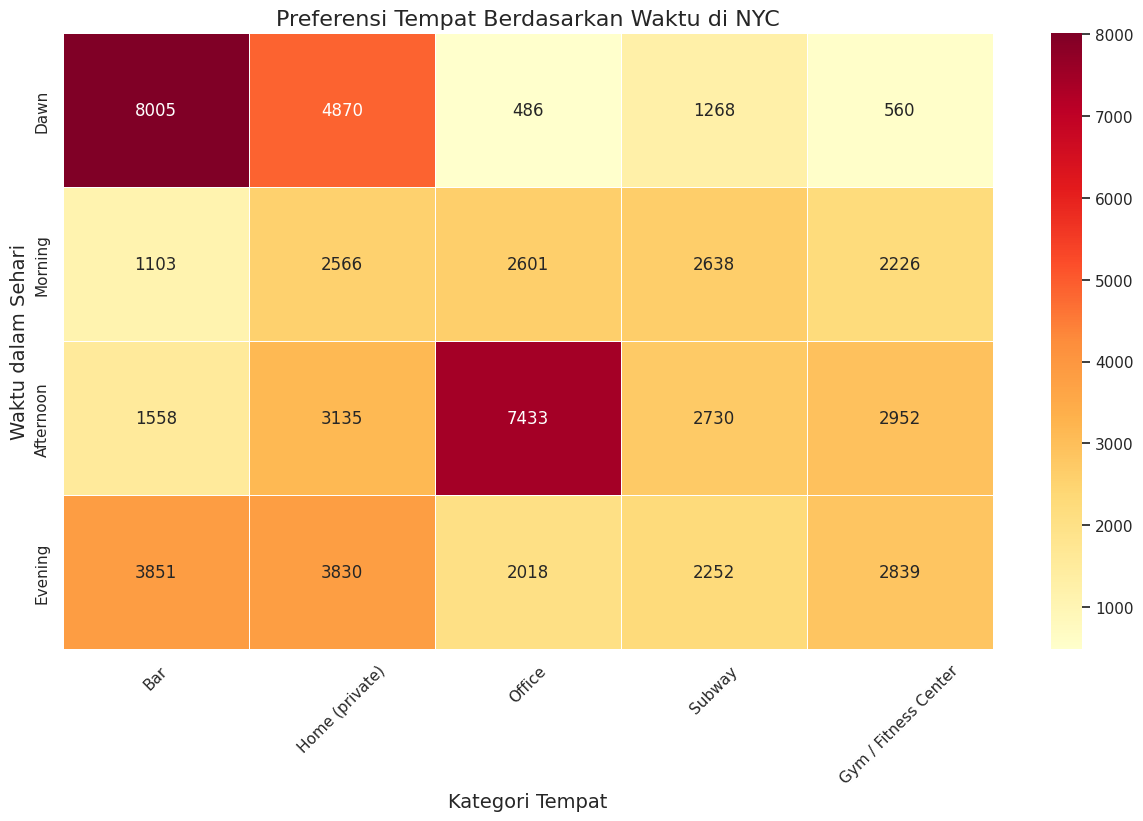


Rekomendasi tempat untuk dikunjungi di NYC:
- Kategori: Bar, Waktu Terbaik: Dawn
- Kategori: Home (private), Waktu Terbaik: Dawn
- Kategori: Office, Waktu Terbaik: Afternoon
- Kategori: Subway, Waktu Terbaik: Afternoon
- Kategori: Gym / Fitness Center, Waktu Terbaik: Afternoon


<ipython-input-3-387d47ca6e95>:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['Hour'] = pd.to_datetime(data['utcTimestamp']).dt.hour


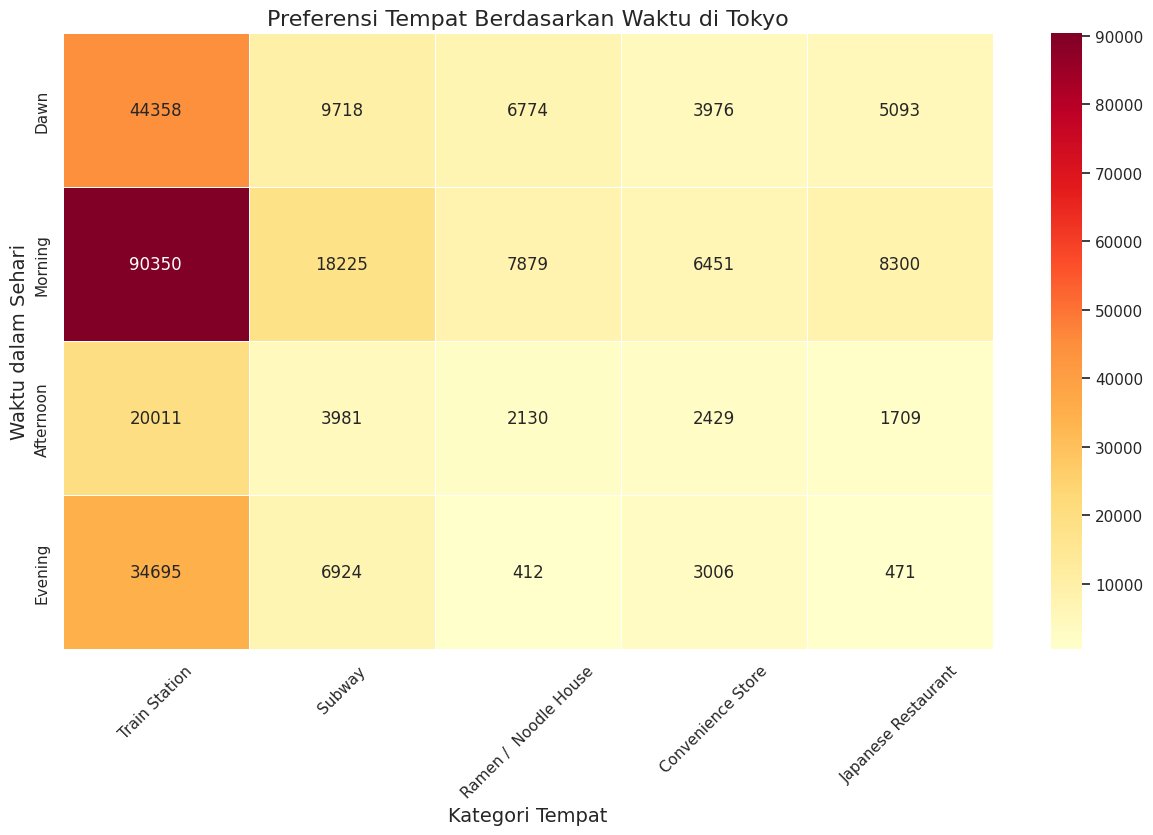


Rekomendasi tempat untuk dikunjungi di Tokyo:
- Kategori: Train Station, Waktu Terbaik: Morning
- Kategori: Subway, Waktu Terbaik: Morning
- Kategori: Ramen /  Noodle House, Waktu Terbaik: Morning
- Kategori: Convenience Store, Waktu Terbaik: Morning
- Kategori: Japanese Restaurant, Waktu Terbaik: Morning


In [4]:
def visualize_preferences(filtered_counts, city_name):
    plt.figure(figsize=(15, 8))
    sns.heatmap(filtered_counts, cmap='YlOrRd', annot=True, fmt='d', linewidths=.5)
    plt.title(f'Preferensi Tempat Berdasarkan Waktu di {city_name}', fontsize=16)
    plt.ylabel('Waktu dalam Sehari', fontsize=14)
    plt.xlabel('Kategori Tempat', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

    # Rekomendasi tempat
    recommended_time = filtered_counts.idxmax(axis=0)
    recommended_places = filtered_counts.max(axis=0)
    print(f"\nRekomendasi tempat untuk dikunjungi di {city_name}:")
    for category, time in zip(recommended_places.index, recommended_time):
        print(f"- Kategori: {category}, Waktu Terbaik: {time}")

# Preprocessing dan visualisasi untuk NYC
filtered_nyc_counts = preprocess_data(nyc_data)
visualize_preferences(filtered_nyc_counts, 'NYC')

# Preprocessing dan visualisasi untuk Tokyo
filtered_tokyo_counts = preprocess_data(tokyo_data)
visualize_preferences(filtered_tokyo_counts, 'Tokyo')

# 2. Bagaimana pola kunjungan pengguna teraktif di berbagai kategori tempat di kota NYC dan Tokyo?

In [5]:
# --- ANALISIS NYC ---
# Mengelompokkan data berdasarkan userId dan venueCategory
nyc_grouped = nyc_data.groupby(['userId', 'venueCategory']).size().reset_index(name='count')

# Mengambil 10 pengguna teratas berdasarkan jumlah kunjungan
top_10_nyc_users = nyc_grouped.groupby('userId')['count'].sum().nlargest(10).index
filtered_nyc_users = nyc_grouped[nyc_grouped['userId'].isin(top_10_nyc_users)]

# --- ANALISIS TOKYO ---
# Mengelompokkan data berdasarkan userId dan venueCategory
tokyo_grouped = tokyo_data.groupby(['userId', 'venueCategory']).size().reset_index(name='count')

# Mengambil 10 pengguna teratas berdasarkan jumlah kunjungan
top_10_tokyo_users = tokyo_grouped.groupby('userId')['count'].sum().nlargest(10).index
filtered_tokyo_users = tokyo_grouped[tokyo_grouped['userId'].isin(top_10_tokyo_users)]


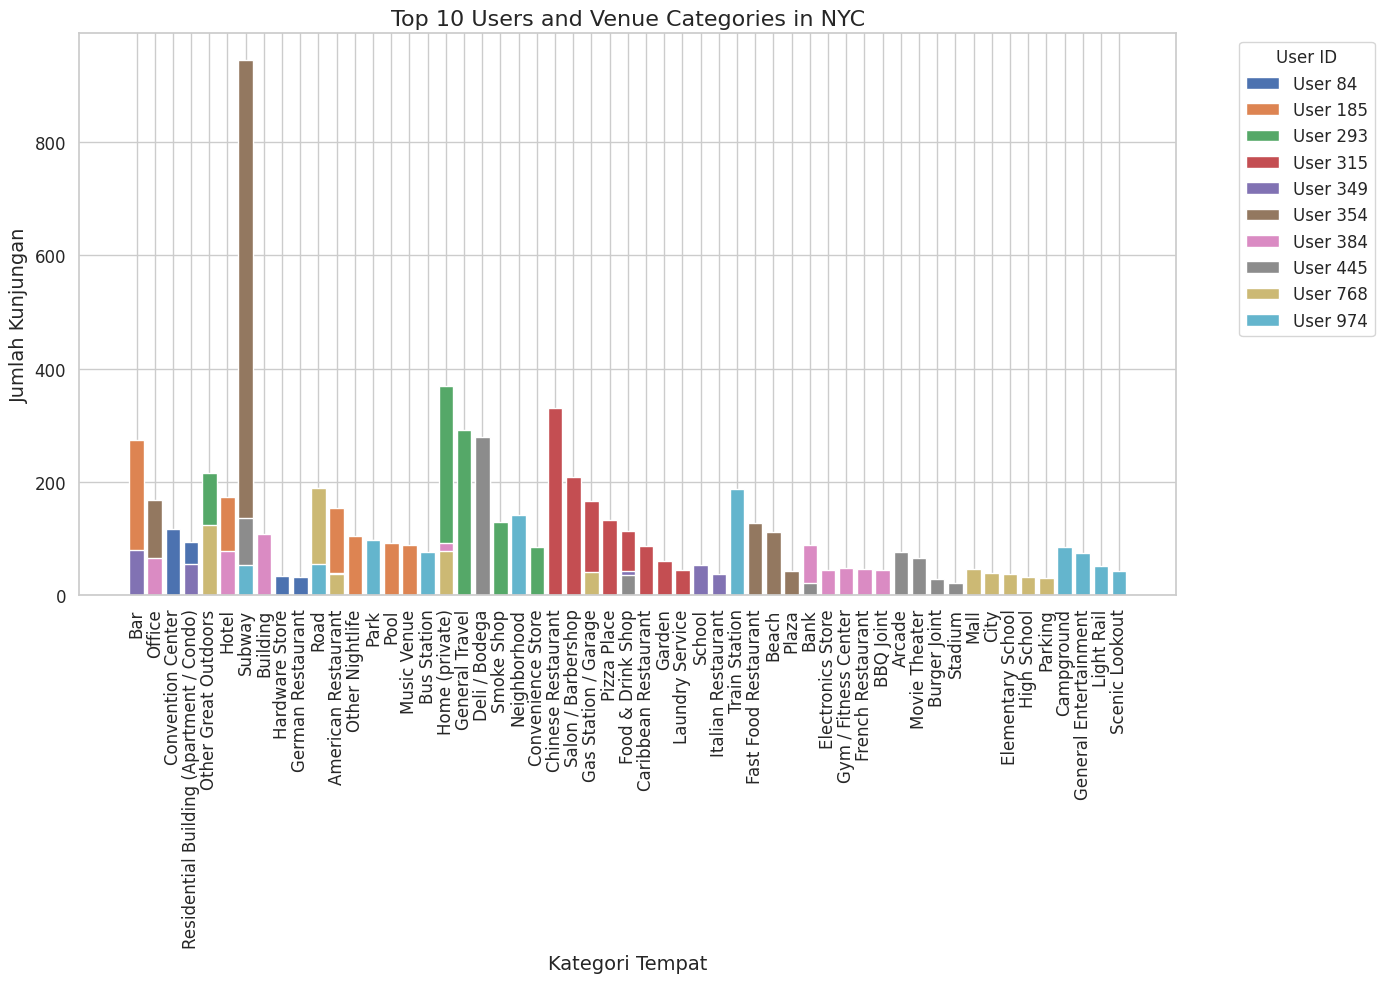

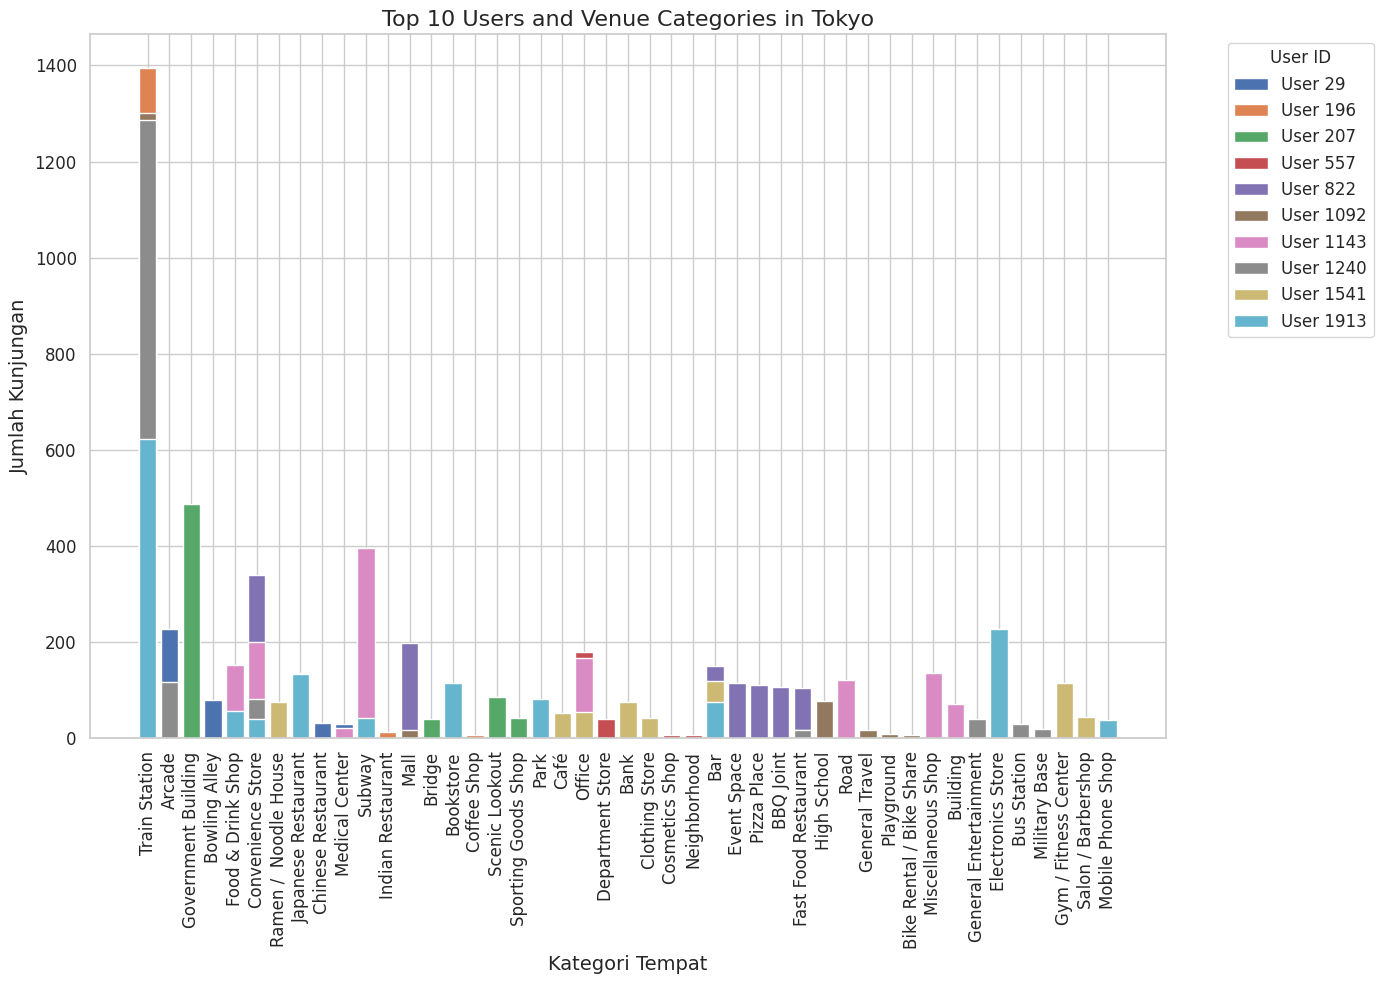

In [6]:
# Membuat visualisasi untuk NYC
plt.figure(figsize=(14, 10))
for user_id in filtered_nyc_users['userId'].unique():
    user_data = filtered_nyc_users[filtered_nyc_users['userId'] == user_id].nlargest(10, 'count')
    plt.bar(user_data['venueCategory'], user_data['count'], label=f'User {user_id}')

plt.title('Top 10 Users and Venue Categories in NYC', fontsize=16)
plt.xlabel('Kategori Tempat', fontsize=14)
plt.ylabel('Jumlah Kunjungan', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='User ID', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

# Membuat visualisasi untuk Tokyo
plt.figure(figsize=(14, 10))
for user_id in filtered_tokyo_users['userId'].unique():
    user_data = filtered_tokyo_users[filtered_tokyo_users['userId'] == user_id].nlargest(10, 'count')
    plt.bar(user_data['venueCategory'], user_data['count'], label=f'User {user_id}')

plt.title('Top 10 Users and Venue Categories in Tokyo', fontsize=16)
plt.xlabel('Kategori Tempat', fontsize=14)
plt.ylabel('Jumlah Kunjungan', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='User ID', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()


# 3. Apa saja lokasi favorit yang sama di kedua kota, dan apakah ada lokasi yang hanya populer di salah satu kota?

Total unique venues in NYC: 251
Total unique venues in Tokyo: 247

Unique to NYC: 4
Unique to Tokyo: 0

Example of Tokyo unique venues:
[]


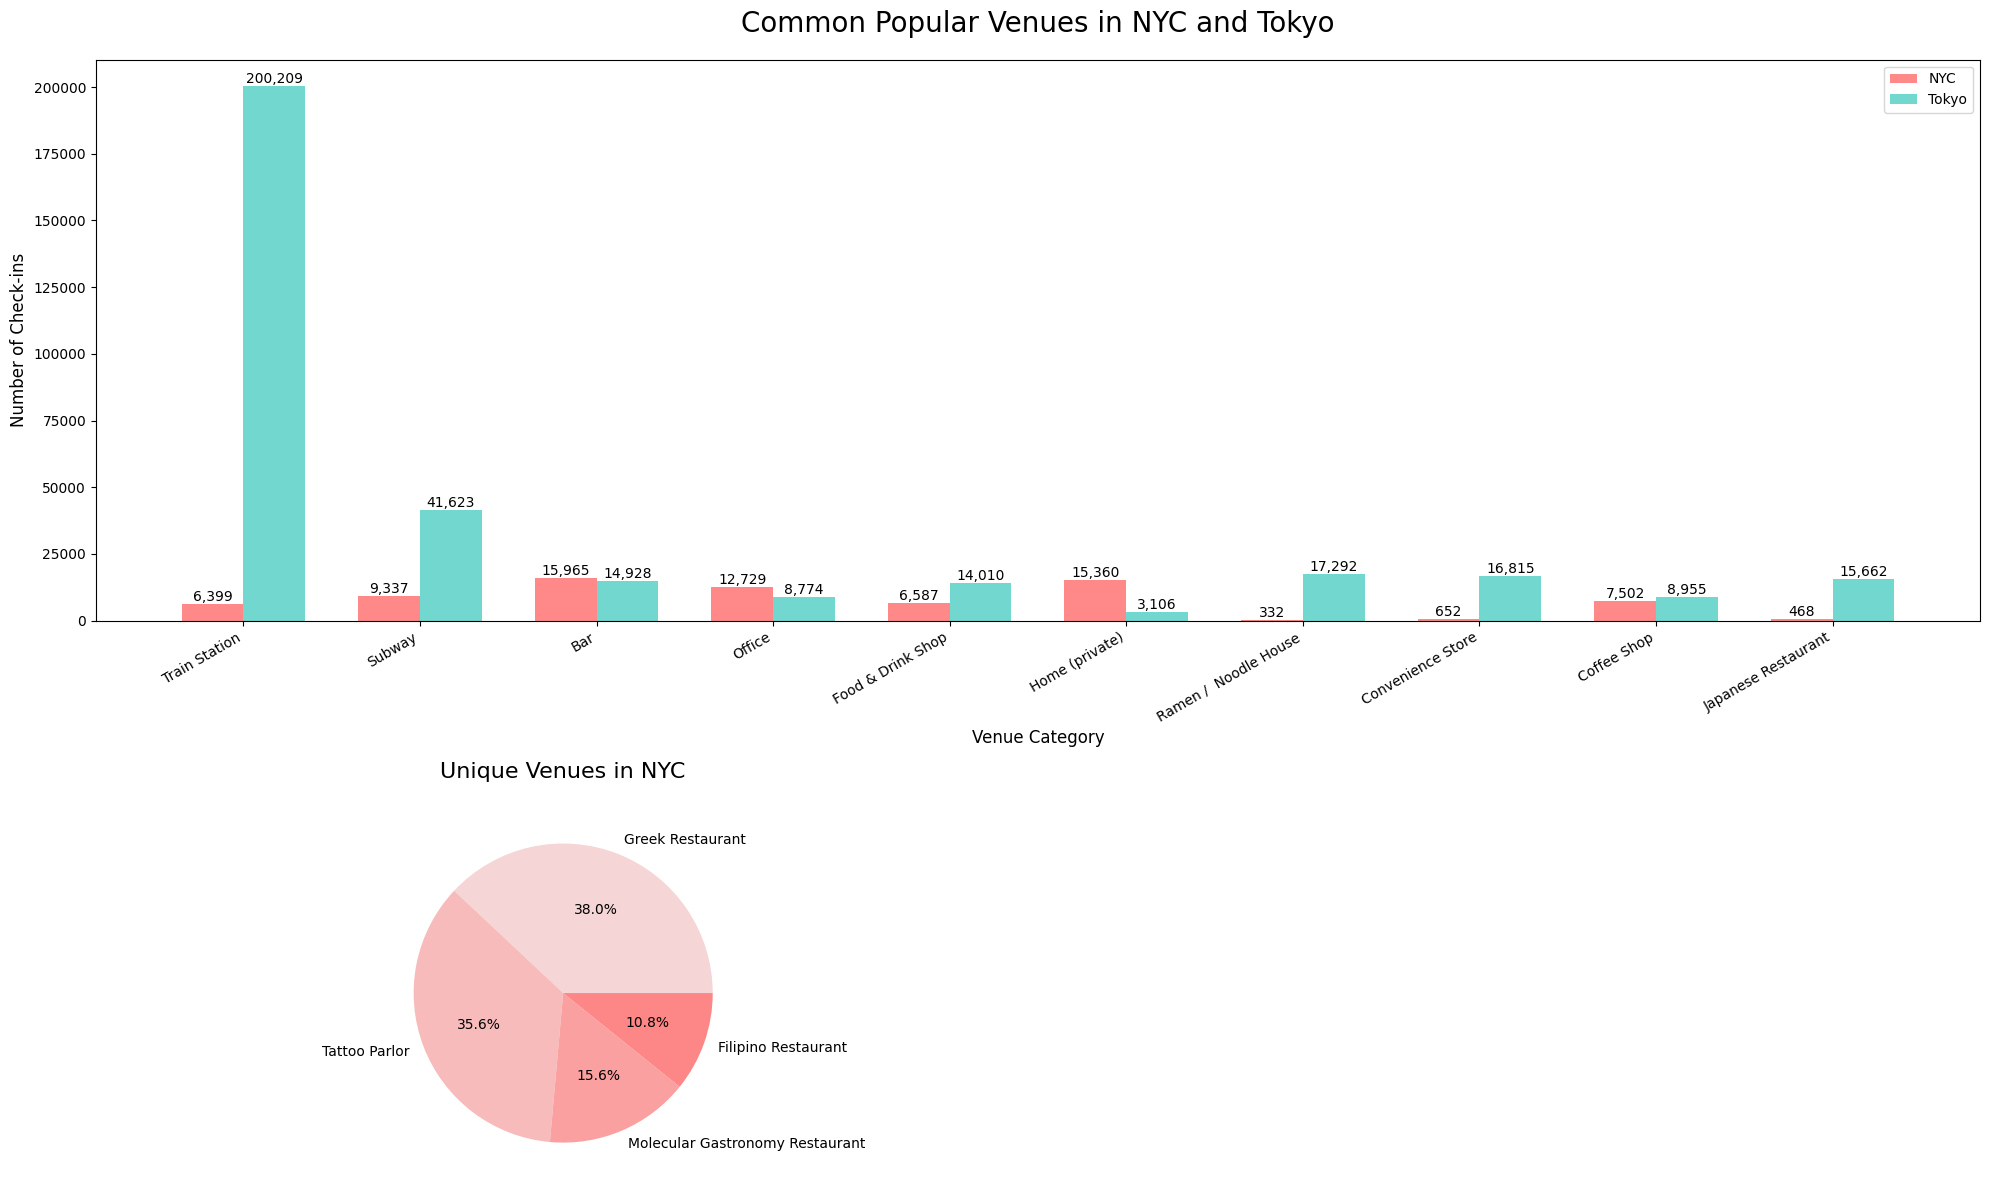

In [14]:
def analyze_venue_comparison(nyc_data, tokyo_data):
    # Set style dan warna
    plt.style.use('default')
    colors_nyc = '#FF6B6B'
    colors_tokyo = '#4ECDC4'

    # Menghitung popularitas venue
    nyc_venues = nyc_data.groupby('venueCategory').size().reset_index(name='count')
    tokyo_venues = tokyo_data.groupby('venueCategory').size().reset_index(name='count')

    # Debug: Print jumlah venue unik di masing-masing kota
    print(f"Total unique venues in NYC: {len(nyc_venues)}")
    print(f"Total unique venues in Tokyo: {len(tokyo_venues)}")

    # Menemukan venue yang sama dan unik
    common_venues = set(nyc_venues['venueCategory']) & set(tokyo_venues['venueCategory'])
    nyc_only = set(nyc_venues['venueCategory']) - set(tokyo_venues['venueCategory'])
    tokyo_only = set(tokyo_venues['venueCategory']) - set(nyc_venues['venueCategory'])

    # Debug: Print jumlah venue yang unik
    print(f"\nUnique to NYC: {len(nyc_only)}")
    print(f"Unique to Tokyo: {len(tokyo_only)}")
    print("\nExample of Tokyo unique venues:")
    print(list(tokyo_only)[:5])

    # DataFrame untuk venue yang sama
    common_data = pd.DataFrame({
        'Category': list(common_venues),
        'NYC': [nyc_venues[nyc_venues['venueCategory'] == cat]['count'].iloc[0] for cat in common_venues],
        'Tokyo': [tokyo_venues[tokyo_venues['venueCategory'] == cat]['count'].iloc[0] for cat in common_venues]
    })
    common_data['Total'] = common_data['NYC'] + common_data['Tokyo']
    common_data = common_data.sort_values('Total', ascending=False)

    # Membuat figure
    fig = plt.figure(figsize=(20, 12))
    gs = plt.GridSpec(2, 2, height_ratios=[1.5, 1])

    # Bar plot untuk venue yang sama
    ax1 = fig.add_subplot(gs[0, :])
    top_common = common_data.head(10)
    x = range(len(top_common))
    width = 0.35

    # Grouped bar chart
    bars1 = ax1.bar([i - width/2 for i in x], top_common['NYC'], width,
                    label='NYC', color=colors_nyc, alpha=0.8)
    bars2 = ax1.bar([i + width/2 for i in x], top_common['Tokyo'], width,
                    label='Tokyo', color=colors_tokyo, alpha=0.8)

    # Styling bar plot
    ax1.set_title('Common Popular Venues in NYC and Tokyo',
                  fontsize=20, pad=20)
    ax1.set_xlabel('Venue Category', fontsize=12)
    ax1.set_ylabel('Number of Check-ins', fontsize=12)
    ax1.set_xticks(x)
    ax1.set_xticklabels(top_common['Category'], rotation=30, ha='right')
    ax1.legend(loc='upper right')

    # Label nilai di atas bar
    def autolabel(bars):
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom')

    autolabel(bars1)
    autolabel(bars2)

    # Pie chart untuk NYC Unique Venues
    ax2 = fig.add_subplot(gs[1, 0])
    nyc_unique_data = nyc_venues[nyc_venues['venueCategory'].isin(nyc_only)].copy()
    nyc_unique_sorted = nyc_unique_data.sort_values('count', ascending=False).head(5)

    if len(nyc_unique_sorted) > 0:
        colors_nyc_pie = sns.light_palette(colors_nyc, n_colors=6)[1:]
        ax2.pie(nyc_unique_sorted['count'], labels=nyc_unique_sorted['venueCategory'],
                autopct='%1.1f%%', colors=colors_nyc_pie)
        ax2.set_title('Unique Venues in NYC', fontsize=16, pad=20)
    else:
        ax2.text(0.5, 0.5, 'No unique venues found in NYC',
                ha='center', va='center')

    plt.tight_layout()
    plt.show()

# Menjalankan analisis
analyze_venue_comparison(nyc_data, tokyo_data)


# 4. Apakah kebiasaan check-in berbeda saat hari kerja dan akhir pekan di kota NYC dan Tokyo?

<ipython-input-12-6202924a0603>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Datetime"] = pd.to_datetime(df["utcTimestamp"])



Total check-ins by day type:
DayType
Weekday    160207
Weekend     66971
Name: count, dtype: int64


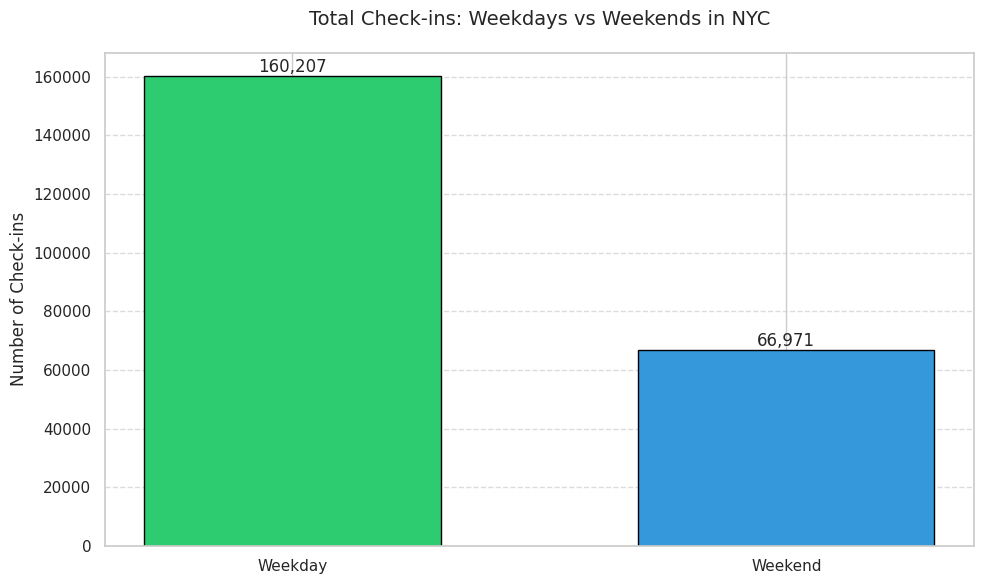

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_total_checkins(df):
    """
    Analyze and visualize total check-ins for weekdays vs weekends

    Parameters:
    df: DataFrame with column 'utcTimestamp'
    """
    # Convert timestamp to datetime
    df["Datetime"] = pd.to_datetime(df["utcTimestamp"])

    # Extract day of week and categorize
    df["DayOfWeek"] = df["Datetime"].dt.day_name()
    df["DayType"] = df["DayOfWeek"].apply(
        lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
    )

    # Calculate totals
    total_by_day_type = df["DayType"].value_counts()

    # Create visualization
    plt.figure(figsize=(10, 6))

    # Create bar plot
    bars = plt.bar(
        total_by_day_type.index,
        total_by_day_type.values,
        color=['#2ecc71', '#3498db'],
        edgecolor='black',
        width=0.6
    )

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom'
        )

    # Customize the plot
    plt.title('Total Check-ins: Weekdays vs Weekends in NYC', fontsize=14, pad=20)
    plt.ylabel('Number of Check-ins', fontsize=12)

    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout
    plt.tight_layout()

    # Return both the plot and the totals
    return plt, total_by_day_type

# Example usage
if __name__ == "__main__":
    # Create sample data
    sample_data = nyc_data

    # Create visualization and get totals
    plt, totals = analyze_total_checkins(sample_data)
    print("\nTotal check-ins by day type:")
    print(totals)
    plt.show()

<ipython-input-13-462adfdb89d4>:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Datetime"] = pd.to_datetime(df["utcTimestamp"])



Total check-ins by day type:
DayType
Weekday    390000
Weekend    183126
Name: count, dtype: int64


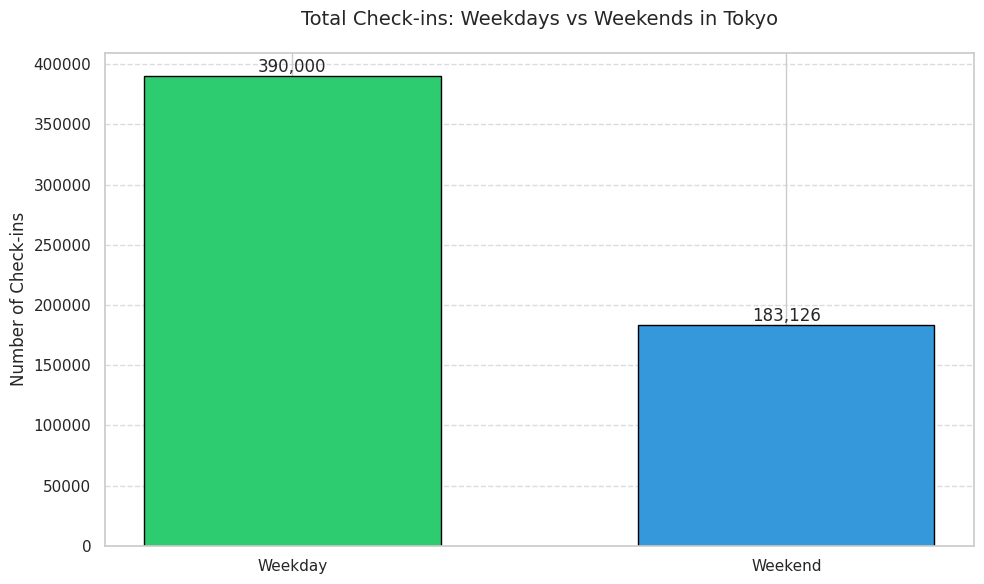

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_total_checkins(df):
    """
    Analyze and visualize total check-ins for weekdays vs weekends

    Parameters:
    df: DataFrame with column 'utcTimestamp'
    """
    # Convert timestamp to datetime
    df["Datetime"] = pd.to_datetime(df["utcTimestamp"])

    # Extract day of week and categorize
    df["DayOfWeek"] = df["Datetime"].dt.day_name()
    df["DayType"] = df["DayOfWeek"].apply(
        lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
    )

    # Calculate totals
    total_by_day_type = df["DayType"].value_counts()

    # Create visualization
    plt.figure(figsize=(10, 6))

    # Create bar plot
    bars = plt.bar(
        total_by_day_type.index,
        total_by_day_type.values,
        color=['#2ecc71', '#3498db'],
        edgecolor='black',
        width=0.6
    )

    # Add value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2.,
            height,
            f'{int(height):,}',
            ha='center',
            va='bottom'
        )

    # Customize the plot
    plt.title('Total Check-ins: Weekdays vs Weekends in Tokyo', fontsize=14, pad=20)
    plt.ylabel('Number of Check-ins', fontsize=12)

    # Add grid for better readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Adjust layout
    plt.tight_layout()

    # Return both the plot and the totals
    return plt, total_by_day_type

# Example usage
if __name__ == "__main__":
    # Create sample data
    sample_data = tokyo_data

    # Create visualization and get totals
    plt, totals = analyze_total_checkins(sample_data)
    print("\nTotal check-ins by day type:")
    print(totals)
    plt.show()